# ** Telecom Dataset Analysis **

## 1) Import the Necessary Libraries 

In [9]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

## 2) Data Collection 🖨️

In [16]:
data = pd.read_csv(r'C:\Users\Kaushal\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [17]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) Data Preprocessing🕵️‍♂️

In [18]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [19]:
#Initially shows no null values, but there is a catch, 
# which I will explain during preprocessing.

In [20]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [21]:
df = data.drop(columns=['customerID','Churn','gender','Partner','Dependents',], axis=1)

In [22]:
df.head()

,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,0,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5
2,0,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,0,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,0,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [23]:
df.columns

Index(['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [24]:
#Get unique values for multiple columns
for i in df.columns:
    print(i, '--', df[i].unique())

SeniorCitizen -- [0 1]
tenure -- [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService -- ['No' 'Yes']
MultipleLines -- ['No phone service' 'No' 'Yes']
InternetService -- ['DSL' 'Fiber optic' 'No']
OnlineSecurity -- ['No' 'Yes' 'No internet service']
OnlineBackup -- ['Yes' 'No' 'No internet service']
DeviceProtection -- ['No' 'Yes' 'No internet service']
TechSupport -- ['No' 'Yes' 'No internet service']
StreamingTV -- ['No' 'Yes' 'No internet service']
StreamingMovies -- ['No' 'Yes' 'No internet service']
Contract -- ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -- ['Yes' 'No']
PaymentMethod -- ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges -- [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges -- ['29.85' '1889.5' '108.15' ... '346.

In [25]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [26]:
service_col = ['OnlineSecurity',
               'OnlineBackup',
               'DeviceProtection',
               'TechSupport',
               'StreamingTV',
               'StreamingMovies']
for i in service_col:
    df[i] = df[i].replace('No internet service', 'No')

## 4) Encoding ( Categories - Numeric )🛠️

In [27]:
#Mapping YES/ No TO 1/0 For easier ML Preprocessing
mapping_col = ['PhoneService',
              'MultipleLines',
              'OnlineSecurity',
              'OnlineBackup',
              'DeviceProtection',
               'TechSupport',
               'StreamingTV',
               'StreamingMovies',
               'PaperlessBilling'
 ]

for i in mapping_col:
    df[i] = df[i].map({'Yes':1, 'No':0})
    

In [28]:
# # Remove leading and trailing spaces from categorical columns

# df['InternetService'] = df['InternetService'].str.strip() #----------- Strip leading/trailing spaces from categorical columns 
#                                                           #------------to avoid duplicate categories (e.g., 'DSL ' vs 'DSL').
# df['Contract'] = df['Contract'].str.strip() 
# df['TotalCharges'] = df['TotalCharges'].str.strip()

In [29]:
df['InternetService'] = df['InternetService'].map({'No':0,'DSL':1,'Fiber optic':2 })
df['Contract'] = df['Contract'].map({'Month-to-month':0, 'One year':1,'Two year':2 })

In [30]:
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True)

In [31]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [32]:
#Detecting the null values after columns(TotalCharges) strg convert to numbers 
#if there is blank space then it will fill Null values.
df.isnull().sum()

SeniorCitizen                             0
tenure                                    0
PhoneService                              0
MultipleLines                             0
InternetService                           0
OnlineSecurity                            0
OnlineBackup                              0
DeviceProtection                          0
TechSupport                               0
StreamingTV                               0
StreamingMovies                           0
Contract                                  0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
PaymentMethod_Credit card (automatic)     0
PaymentMethod_Electronic check            0
PaymentMethod_Mailed check                0
dtype: int64

In [33]:
# Detected 11 Null Values
# After converting TotalCharges column(Strg) to numeric, blank spaces became NaN values. 
# These blanks likely represent new customers with no charges yet, 

In [34]:
df['TotalCharges'].fillna(0, inplace=True)  #Fill thoes null values 

In [35]:
# Find boolean columns and change into int.
bool_cols = df.select_dtypes(include='bool').columns
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)

In [36]:
df.isnull().sum()

SeniorCitizen                            0
tenure                                   0
PhoneService                             0
MultipleLines                            0
InternetService                          0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64

In [37]:
# Scale the data
scaler = StandardScaler()
x_cluster = scaler.fit_transform(df)

In [38]:
df.isnull().sum()

SeniorCitizen                            0
tenure                                   0
PhoneService                             0
MultipleLines                            0
InternetService                          0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
Contract                                 0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
dtype: int64

## 5) Find Optimal K = ?🪸

In [39]:
df.head()

,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,0,1,0,1,0,0,0,0,0,1,29.85,29.85,0,1,0
1,0,34,1,0,1,1,0,1,0,0,0,1,0,56.95,1889.50,0,0,1
2,0,2,1,0,1,1,1,0,0,0,0,0,1,53.85,108.15,0,0,1
3,0,45,0,0,1,1,0,1,1,0,0,1,0,42.30,1840.75,0,0,0
4,0,2,1,0,2,0,0,0,0,0,0,0,1,70.70,151.65,0,1,0


In [40]:
wcss = []
silhoette_scores = []
for i in range(2,12):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++'
    )
    
    kmeans.fit(x_cluster)
    wcss.append(kmeans.inertia_)
    si_score = silhouette_score(x_cluster,kmeans.labels_)
    silhoette_scores.append(si_score)

  File "C:\Users\Kaushal\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Kaushal\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kaushal\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Kaushal\anaconda3\Lib\sub

In [41]:
silhoette_scores #------Evaluate the quality of clusters 

[np.float64(0.19718175496238308),
 np.float64(0.17795532036125739),
 np.float64(0.14473444225687904),
 np.float64(0.15677300762967886),
 np.float64(0.1580496550273037),
 np.float64(0.14875254174638897),
 np.float64(0.14037069429353458),
 np.float64(0.14760605395716533),
 np.float64(0.12700309723002048),
 np.float64(0.14856511234340855)]

# 6) ELbow Method to find optimal K 📈

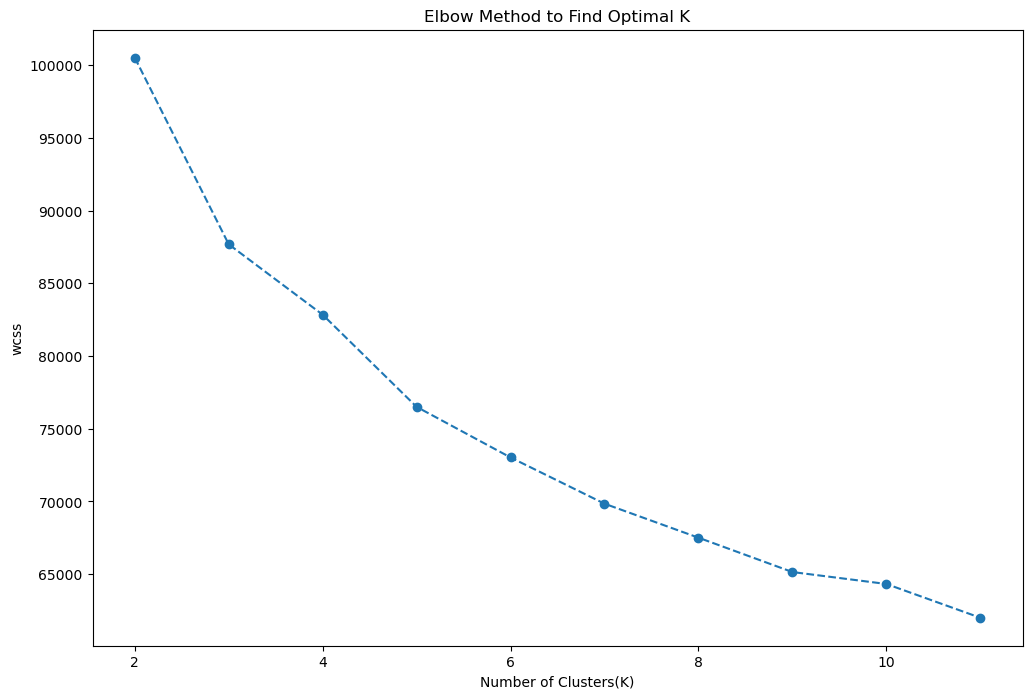

In [42]:
#Help to choose the optimal number of Clusters(K) in Kmeans
plt.figure(figsize=(12,8))
plt.plot(range(2,12), wcss,marker='o', linestyle='--')
plt.xlabel('Number of Clusters(K)')
plt.ylabel('wcss')
plt.title('Elbow Method to Find Optimal K')
plt.show()

## 7) Hierarchical Clustering🏯

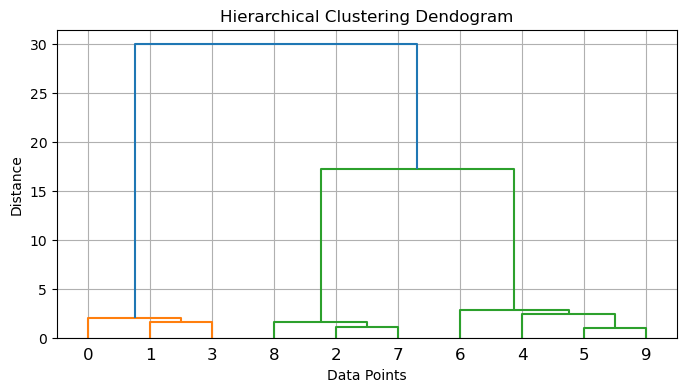

In [45]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

#sample Data 
x_demo,_ = make_blobs(n_samples=10, centers=3, random_state=42)

#linkage matrix
linked = linkage(x_demo, method= 'ward')

#plot dendogram
plt.figure(figsize=(8,4))
dendrogram(linked, orientation= 'top', distance_sort='decending', show_leaf_counts= True)
plt.title('Hierarchical Clustering Dendogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.grid(True)
plt.show()


# Cutting at height = 15 might give you 3 clusters.

## 8) Assign clusters🚩

In [48]:
kmeans_model = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(x_cluster)

In [49]:
df.columns

Index(['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Cluster'],
      dtype='object')

## 9) Cluster Summary🗼

In [50]:
df.groupby('Cluster')[['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Cluster']].mean()

,SeniorCitizen,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Cluster
Cluster,,,,,,,,,,,,,,,,,,,
0,0.152493,31.737537,0.0,0.000000,1.000000,0.414956,0.420821,0.447214,0.423754,0.417889,0.436950,0.684751,0.567449,42.028592,1496.033651,0.225806,0.331378,0.233138,0.0
1,0.259843,17.212184,1.0,0.479072,1.782429,0.180688,0.281807,0.260257,0.170742,0.406133,0.402818,0.070452,0.764194,79.458206,1399.875591,0.112308,0.641939,0.091587,1.0
2,0.177268,57.270073,1.0,0.734619,1.619917,0.595933,0.706986,0.732013,0.629823,0.737748,0.745047,1.267987,0.668926,92.302138,5314.744447,0.352972,0.232534,0.089677,2.0
3,0.034975,27.077833,1.0,0.200000,0.257635,0.077340,0.052217,0.041872,0.066502,0.013300,0.016256,0.883744,0.323645,28.908842,721.327143,0.206897,0.070936,0.522167,3.0


## 10) Conclusion🎯

This analysis is based on **subscription-based customer data**, where each customer pays recurring monthly charges for core services and optional add-ons. Using clustering, customers were segmented into **four distinct groups** based on tenure, service usage, and spending behavior.

The results show clear differences in **customer value and engagement**:

### • Cluster 2 — High-Value Loyal Customers
- Longest tenure  
- Highest monthly and total charges  
- Strong adoption of value-added services (online security, backups, streaming)  

These customers are loyal, long-term subscribers and contribute the highest revenue.

### • Cluster 1 — High-Spending but New Customers
- High monthly charges  
- Short tenure  
- Moderate service adoption  

This group is critical from a **retention perspective**, as they show a higher risk of churn.

### • Cluster 0 — Moderate and Stable Users
- Average spending  
- Medium tenure  
- Primarily internet-service users  

This segment shows strong potential for **upselling**, especially phone services or premium add-ons.

### • Cluster 3 — Low-Usage Budget Customers
- Lowest monthly charges  
- Minimal add-on usage  
- Low overall revenue contribution  

Targeted low-cost plans or awareness campaigns may help increase engagement.

In [52]:
# Save the model along with Scaler
import joblib

model_path = 'kmeans_Model.joblib'
joblib.dump(kmeans_model, model_path)

vect_path = 'Scaler.joblib'
joblib.dump(scaler, vect_path)

df.to_csv("customer_segments.csv", index=False)